In [4]:
import pandas as pd
from underthesea import word_tokenize
import matplotlib.pyplot as plt
from transformers import AutoTokenizer,AutoConfig
import re
from sklearn.model_selection import train_test_split
import torch
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
from transformers import AutoModelForSequenceClassification
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
import time
import os



d:\NLP_Project\SMS\venv_sms\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [5]:
df=pd.read_csv(r"D:\NLP_Project\CUOI_KY\data.csv")

# Tách từ (Word Segment)

In [6]:
pd.set_option('display.max_colwidth', None)

In [7]:
df["tokens"] = df["review"].apply(
    lambda x: word_tokenize(str(x), format="text")
)

In [8]:
df["tokens"]

0                                                                                                                                                                                                                                                                                                        hương_vị : thom chắc do bên giao hàng bị vỡ mấy gói
1                                                                                                                                                                                                 hương thơm : nhẹ_nhàng lợi_ích : phục_hồi cấp ẩm_mẹo : không có shop đóng_gói cẩn_thận chu_đáo lắm ship nhanh shiper thân_thiện sẽ ủng_hộ tiếp_tục nha tks
2                                                                                                                                                                                                   chất_lượng sản_phẩm : ok đúng với mô_tả : đúng lần đầu mua ở shop . đóng_gói kĩ , sản_phẩm chất_lượng , dễ

# Xóa dấu câu

In [9]:
def clean_text(text):
    text = str(text)
    text = text.lower()

    # 1. chuẩn hóa !!! và ???
    text = re.sub(r"!+", "!", text)
    text = re.sub(r"\?+", "?", text)

    # 2. xóa dấu câu không cần
    text = re.sub(r"[:;(),\"']", " ", text)

    # 3. xóa khoảng trắng thừa
    text = re.sub(r"\s+", " ", text).strip()

    return text

In [10]:
df["text_clean"] = df["tokens"].apply(clean_text)

In [11]:
df["text_clean"].head()

0                                                                                                                                                                                                                                                                                                 hương_vị thom chắc do bên giao hàng bị vỡ mấy gói
1                                                                                                                                                                                              hương thơm nhẹ_nhàng lợi_ích phục_hồi cấp ẩm_mẹo không có shop đóng_gói cẩn_thận chu_đáo lắm ship nhanh shiper thân_thiện sẽ ủng_hộ tiếp_tục nha tks
2                                                                                                                                                                                                  chất_lượng sản_phẩm ok đúng với mô_tả đúng lần đầu mua ở shop . đóng_gói kĩ sản_phẩm chất_lượng dễ dán . nên mua nha . mình s

# Mã hóa câu (Encode)

In [12]:
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base")

In [13]:
max_length=256
encoded = tokenizer(
    df["text_clean"].tolist(),
    padding=True,
    truncation=True,
    max_length=max_length,
    return_tensors="pt"
)

## Đếm số token thật
Mục đích để chọn độ dài chuỗi

In [14]:
df["word_token_count"] = encoded["attention_mask"].sum(dim=1).numpy() - 2

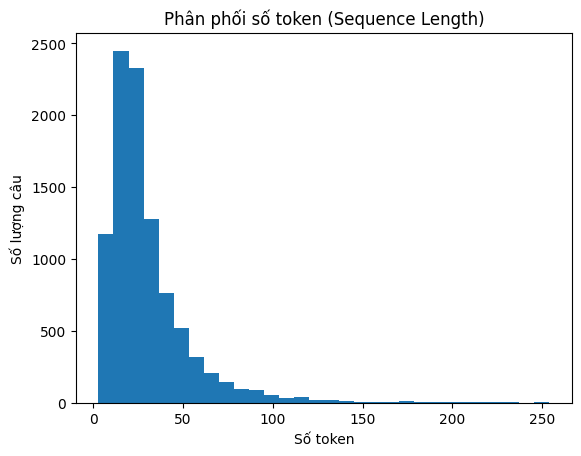

In [15]:
plt.figure()
plt.hist(df["word_token_count"], bins=30)
plt.title("Phân phối số token (Sequence Length)")
plt.xlabel("Số token")
plt.ylabel("Số lượng câu")
plt.show()

In [16]:
# Chọn max_length=150
true_max_length = 150


# Chia Train Validation Test

In [17]:
X = df["text_clean"]
y = df["label"]

# Train + Temp(0.5 val 0.5 test)
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

# Val + Test

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)



# Tokenize

In [18]:
train=tokenizer(X_train.tolist(),padding=True,truncation=True,max_length=true_max_length,return_tensor='pt')

val=tokenizer(X_val.tolist(),padding=True,truncation=True,max_length=true_max_length,return_tensor='pt')

test=tokenizer(X_test.tolist(),padding=True,truncation=True,max_length=true_max_length,return_tensor='pt')

# Tạo DataSet Pytorch

In [20]:
import torch
from torch.utils.data import Dataset

class PhoBERTDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels.values

    def __getitem__(self, idx):
        item = {
            "input_ids": torch.tensor(self.encodings["input_ids"][idx]),
            "attention_mask": torch.tensor(self.encodings["attention_mask"][idx]),
            "labels": torch.tensor(self.labels[idx])
        }
        return item

    def __len__(self):
        return len(self.labels)

In [21]:
train_dataset = PhoBERTDataset(train, y_train)
val_dataset = PhoBERTDataset(val, y_val)
test_dataset = PhoBERTDataset(test, y_test)

# DataLoader

In [22]:
train_loader=DataLoader(train_dataset,batch_size=32,shuffle=True)
val_loader=DataLoader(val_dataset,batch_size=32)

In [45]:
test_loader=DataLoader(test_dataset,batch_size=32)

In [23]:
batch = next(iter(train_loader))
print(type(batch))
print(batch.keys())
print(type(batch["input_ids"]))

<class 'dict'>
dict_keys(['input_ids', 'attention_mask', 'labels'])
<class 'torch.Tensor'>


# Tải mô hình PhoBERT Classification

In [32]:
config = AutoConfig.from_pretrained(
    "vinai/phobert-base",
    num_labels=2,
    hidden_dropout_prob=0.3,
    attention_probs_dropout_prob=0.1
)

model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base",
    config=config
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 24651.77it/s]
RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
classifier.dense.bias           | MISSING    | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.out_proj.bias        | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok i

# Tối ưu (Optimizer)

In [33]:
no_decay = ["bias", "LayerNorm.weight"]

optimizer_grouped_parameters = [
    {
        "params": [p for n, p in model.named_parameters() if not any(nd in n for nd in no_decay)],
        "weight_decay": 0.01,
    },
    {
        "params": [p for n, p in model.named_parameters() if any(nd in n for nd in no_decay)],
        "weight_decay": 0.0,
    },
]

optimizer = AdamW(optimizer_grouped_parameters, lr=1e-4)

EPOCHS = 12

total_steps = len(train_loader) * EPOCHS

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(0.1 * total_steps),
    num_training_steps=total_steps
)

# Huấn Luyện Mô Hình (Train + Validation Loop)

## Config

In [34]:
SAVE_EVERY = 2
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

save_dir = "checkpoints_reglu_2"
os.makedirs(save_dir, exist_ok=True)

model.to(device)

RobertaForSequenceClassification(
  (roberta): RobertaModel(
    (embeddings): RobertaEmbeddings(
      (word_embeddings): Embedding(64001, 768, padding_idx=1)
      (token_type_embeddings): Embedding(1, 768)
      (LayerNorm): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.3, inplace=False)
      (position_embeddings): Embedding(258, 768, padding_idx=1)
    )
    (encoder): RobertaEncoder(
      (layer): ModuleList(
        (0-11): 12 x RobertaLayer(
          (attention): RobertaAttention(
            (self): RobertaSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.1, inplace=False)
            )
            (output): RobertaSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
             

## Hàm Train

In [36]:
def train_one_epoch(model, train_loader, optimizer, device, epoch, train_losses):
    model.train()
    
    total_loss = 0
    running_loss = 0

    for i, batch in enumerate(train_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()

        total_loss += loss.item()
        running_loss += loss.item()

        # log mỗi 10 batch
        if (i + 1) % 10 == 0 or (i + 1) == len(train_loader):
            avg_10 = running_loss / ((i % 10) + 1)
            train_losses.append(round(avg_10, 5))

            print(f"[Train] Epoch {epoch+1} | Batch {i+1}/{len(train_loader)} | Loss: {avg_10:.4f}")

            running_loss = 0

    avg_loss = total_loss / len(train_loader)
    return avg_loss


In [37]:
def validate_one_epoch(model, val_loader, device, epoch, val_losses):
    model.eval()
    
    total_loss = 0
    running_loss = 0

    with torch.no_grad():
        for i, batch in enumerate(val_loader):
            batch = {k: v.to(device) for k, v in batch.items()}

            outputs = model(**batch)
            loss = outputs.loss

            total_loss += loss.item()
            running_loss += loss.item()

            if (i + 1) % 10 == 0 or (i + 1) == len(val_loader):
                avg_10 = running_loss / ((i % 10) + 1)
                val_losses.append(round(avg_10, 5))

                print(f"[Val]   Epoch {epoch+1} | Batch {i+1}/{len(val_loader)} | Loss: {avg_10:.4f}")

                running_loss = 0

    avg_loss = total_loss / len(val_loader)
    return avg_loss


In [43]:
""" 

resume_path = r"D:\NLP_Project\CUOI_KY\checkpoints_reglu\model_epoch_6.pt"
checkpoint = torch.load(resume_path, map_location=device)

model.load_state_dict(checkpoint['model_state_dict'])
optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

start_epoch = checkpoint['epoch']

train_losses = checkpoint.get('train_losses', [])
val_losses = checkpoint.get('val_losses', [])

print(f"Resume từ epoch {start_epoch}")

"""

SyntaxError: (unicode error) 'unicodeescape' codec can't decode bytes in position 21-22: malformed \N character escape (3364147591.py, line 1)

In [38]:
resume_path = None  # ví dụ: "checkpoints_reglu/model_epoch_2.pt"

if resume_path is not None:
    checkpoint = torch.load(resume_path)

    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    
    start_epoch = checkpoint['epoch']

    train_losses = checkpoint.get('train_losses', [])
    val_losses = checkpoint.get('val_losses', [])

    print(f"Resume từ epoch {start_epoch}")
else:
    start_epoch = start_epoch
    train_losses = []
    val_losses = []
    start_epoch=0
print(f"star epoch truoc main {start_epoch}")
# MAIN TRAIN LOOP

for epoch in range(start_epoch, EPOCHS):
    print(f"\n===== Epoch {start_epoch+1} =====")
    epoch_start = time.time()

    # TRAIN
    train_start = time.time()
    avg_train_loss = train_one_epoch(
        model, train_loader, optimizer, device, epoch, train_losses
    )
    train_time = time.time() - train_start

    # VALIDATION
    val_start = time.time()
    avg_val_loss = validate_one_epoch(
        model, val_loader, device, epoch, val_losses
    )
    val_time = time.time() - val_start

    epoch_time = time.time() - epoch_start

    # LOG
    print(f"\n===== Epoch {epoch+1} Summary =====")
    print(f"Train Loss: {avg_train_loss:.4f}")
    print(f"Val Loss:   {avg_val_loss:.4f}")
    print(f"Train Time: {train_time:.2f}s")
    print(f"Val Time:   {val_time:.2f}s")
    print(f"Total Time: {epoch_time:.2f}s")
    print("-" * 40)

    # 
    # SAVE CHECKPOINT
    # 
    if (epoch + 1) % SAVE_EVERY == 0:
        save_path = os.path.join(save_dir, f"model_epoch_{epoch+1}.pt")

        torch.save({
            'epoch': epoch + 1,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),

            #  history loss mỗi 10 batch
            'train_losses': train_losses,
            'val_losses': val_losses,

            #  avg loss 1 epoch
            'avg_train_loss': avg_train_loss,
            'avg_val_loss': avg_val_loss

        }, save_path)

        print(f" Saved model: {save_path}")

star epoch truoc main 0

===== Epoch 1 =====
[Train] Epoch 1 | Batch 10/210 | Loss: 0.7052
[Train] Epoch 1 | Batch 20/210 | Loss: 0.6887
[Train] Epoch 1 | Batch 30/210 | Loss: 0.6494
[Train] Epoch 1 | Batch 40/210 | Loss: 0.6514
[Train] Epoch 1 | Batch 50/210 | Loss: 0.6377
[Train] Epoch 1 | Batch 60/210 | Loss: 0.6132
[Train] Epoch 1 | Batch 70/210 | Loss: 0.5635
[Train] Epoch 1 | Batch 80/210 | Loss: 0.5293
[Train] Epoch 1 | Batch 90/210 | Loss: 0.3919
[Train] Epoch 1 | Batch 100/210 | Loss: 0.4039
[Train] Epoch 1 | Batch 110/210 | Loss: 0.2949
[Train] Epoch 1 | Batch 120/210 | Loss: 0.2146
[Train] Epoch 1 | Batch 130/210 | Loss: 0.2284
[Train] Epoch 1 | Batch 140/210 | Loss: 0.3531
[Train] Epoch 1 | Batch 150/210 | Loss: 0.3272
[Train] Epoch 1 | Batch 160/210 | Loss: 0.3058
[Train] Epoch 1 | Batch 170/210 | Loss: 0.1921
[Train] Epoch 1 | Batch 180/210 | Loss: 0.3044
[Train] Epoch 1 | Batch 190/210 | Loss: 0.1463
[Train] Epoch 1 | Batch 200/210 | Loss: 0.2369
[Train] Epoch 1 | Batch 

KeyboardInterrupt: 

In [ ]:
save_dir = "checkpoints"

train_curve = []
val_curve = []

epochs = []

for file in sorted(os.listdir(save_dir)):
    if file.endswith(".pt"):
        path = os.path.join(save_dir, file)
        checkpoint = torch.load(path, map_location="cpu")

        epochs.append(checkpoint["epoch"])
        train_curve.append(checkpoint["avg_train_loss"])
        val_curve.append(checkpoint["avg_val_loss"])

# Đánh giá model trước Relugration

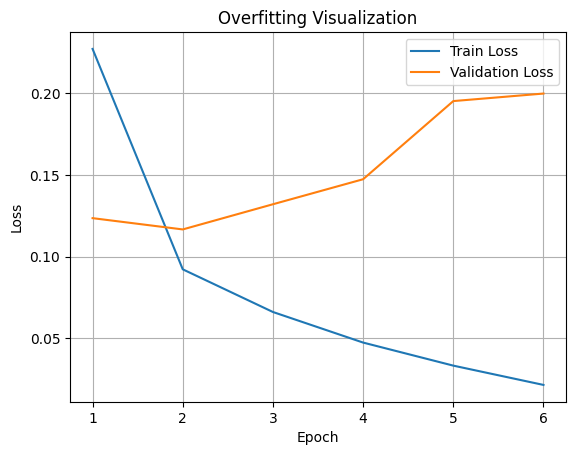

In [ ]:
epochs = list(range(1, len(avg_train)+1))

plt.figure()
plt.plot(epochs, avg_train, label="Train Loss")
plt.plot(epochs, avg_val, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Overfitting Visualization")
plt.legend()
plt.grid()

plt.show()

# Đánh giá mô hình tập test

In [49]:
all_probs = []
all_labels = []
total_loss = 0

model.eval()

with torch.no_grad():
    for i, batch in enumerate(test_loader):
        batch = {k: v.to(device) for k, v in batch.items()}

        outputs = model(**batch)
        loss = outputs.loss
        logits = outputs.logits

        total_loss += loss.item()

        probs = torch.softmax(logits, dim=-1)
        prob_class1 = probs[:, 1]

        all_probs.extend(prob_class1.cpu().numpy())
        all_labels.extend(batch["labels"].cpu().numpy())

        print(f"Batch {i+1} Loss: {loss.item():.4f}")

avg_loss = total_loss / len(test_loader)
print(f"\nAverage Test Loss: {avg_loss:.4f}")

Batch 1 Loss: 0.0539
Batch 2 Loss: 0.2557
Batch 3 Loss: 0.2719
Batch 4 Loss: 0.2965
Batch 5 Loss: 0.1527
Batch 6 Loss: 0.1010
Batch 7 Loss: 0.1170
Batch 8 Loss: 0.3178
Batch 9 Loss: 0.0984
Batch 10 Loss: 0.1800
Batch 11 Loss: 0.0753
Batch 12 Loss: 0.0765
Batch 13 Loss: 0.0821
Batch 14 Loss: 0.0104
Batch 15 Loss: 0.1128
Batch 16 Loss: 0.1796
Batch 17 Loss: 0.0868
Batch 18 Loss: 0.0281
Batch 19 Loss: 0.2265
Batch 20 Loss: 0.0225
Batch 21 Loss: 0.1000
Batch 22 Loss: 0.0256
Batch 23 Loss: 0.0236
Batch 24 Loss: 0.0854
Batch 25 Loss: 0.1352
Batch 26 Loss: 0.0499
Batch 27 Loss: 0.1049
Batch 28 Loss: 0.3229
Batch 29 Loss: 0.0552
Batch 30 Loss: 0.0737
Batch 31 Loss: 0.0554
Batch 32 Loss: 0.2591
Batch 33 Loss: 0.0831
Batch 34 Loss: 0.1434
Batch 35 Loss: 0.2329
Batch 36 Loss: 0.0951
Batch 37 Loss: 0.0277
Batch 38 Loss: 0.0660
Batch 39 Loss: 0.0149
Batch 40 Loss: 0.1050
Batch 41 Loss: 0.0541
Batch 42 Loss: 0.0274
Batch 43 Loss: 0.1732
Batch 44 Loss: 0.2371
Batch 45 Loss: 0.0273

Average Test Loss:

In [51]:
import pandas as pd
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

results = []

for th in thresholds:
    preds = (all_probs > th).astype(int)

    acc = accuracy_score(all_labels, preds)

    results.append({
        "Threshold": th,
        "Accuracy": acc,

        # class 1
        "Precision_1": precision_score(all_labels, preds, pos_label=1),
        "Recall_1": recall_score(all_labels, preds, pos_label=1),
        "F1_1": f1_score(all_labels, preds, pos_label=1),

        # class 0
        "Precision_0": precision_score(all_labels, preds, pos_label=0),
        "Recall_0": recall_score(all_labels, preds, pos_label=0),
        "F1_0": f1_score(all_labels, preds, pos_label=0),
    })

df = pd.DataFrame(results).round(4)

print(df)

   Threshold  Accuracy  Precision_1  Recall_1    F1_1  Precision_0  Recall_0  \
0        0.3    0.9472       0.9036    0.9633  0.9325       0.9767    0.9374   
1        0.4    0.9542       0.9239    0.9578  0.9405       0.9737    0.9520   
2        0.5    0.9549       0.9332    0.9486  0.9409       0.9684    0.9587   
3        0.6    0.9542       0.9411    0.9376  0.9393       0.9621    0.9642   
4        0.7    0.9549       0.9511    0.9284  0.9396       0.9570    0.9709   
5        0.8    0.9562       0.9653    0.9174  0.9407       0.9512    0.9799   

     F1_0  
0  0.9567  
1  0.9627  
2  0.9635  
3  0.9632  
4  0.9639  
5  0.9653  


# Ma Trận Nhầm Lẫn với threshold =0.3

In [59]:
from sklearn.metrics import confusion_matrix

th = 0.3

all_probs = np.array(all_probs)   # 🔥 FIX
all_labels = np.array(all_labels)

preds = (all_probs > th).astype(int)

cm = confusion_matrix(all_labels, preds)

cm_df = pd.DataFrame(
    cm,
    index=["Actual 0", "Actual 1"],
    columns=["Pred 0", "Pred 1"]
)

print(cm_df)

          Pred 0  Pred 1
Actual 0     839      56
Actual 1      20     525


#